In [ ]:
!pip install gymnasium stable-baselines3 yfinance ta matplotlib pandas numpy scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 8.2 MB/s eta 0:00:00
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=93259b03bfd52b6570a2ea1a09534d1f4e0ef7c200424d7f24a3e67ab58a1c6d
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta

In [5]:
stocks = [
    "AAPL",   # Apple
    "MSFT",   # Microsoft
    "GOOG",   # Google
    "AMZN",   # Amazon
    "META",   # Meta
    "NVDA",   # Nvidia
    "TSLA",   # Tesla
    "JPM",    # JPMorgan
    "KO",     # Coca-Cola
    "PEP"     # PepsiCo
]

start_date = "2018-01-01"
end_date = "2024-12-31"

In [6]:
all_data = []

for ticker in stocks:

    print(f"Downloading {ticker}...")

    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False
    )
    data.columns = data.columns.get_level_values(0)

    data.reset_index(inplace=True)

    data["ticker"] = ticker

    data = data[
        [
            "Date",
            "ticker",
            "Open",
            "High",
            "Low",
            "Close",
            "Volume"
        ]
    ]

    all_data.append(data)

raw_data = pd.concat(all_data, ignore_index=True)

raw_data.sort_values(
    by=["ticker", "Date"],
    inplace=True
)

raw_data.reset_index(drop=True, inplace=True)
raw_data.info()
display(raw_data.head(20))
print("=" * 60)
print("Data Download Summary")
print("=" * 60)

print(f"Total rows downloaded : {len(raw_data)}")
print(f"Number of stocks      : {raw_data['ticker'].nunique()}")

print("\nRows per stock:\n")
print(raw_data["ticker"].value_counts())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17600 entries, 0 to 17599
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    17600 non-null  datetime64[ns]
 1   ticker  17600 non-null  object        
 2   Open    17600 non-null  float64       
 3   High    17600 non-null  float64       
 4   Low     17600 non-null  float64       
 5   Close   17600 non-null  float64       
 6   Volume  17600 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 962.6+ KB


Price,Date,ticker,Open,High,Low,Close,Volume
0,2018-01-02,AAPL,39.741903,40.241713,39.531700,40.232368,102223600
1,2018-01-03,AAPL,40.295436,40.767220,40.162311,40.225368,118071600
2,2018-01-04,AAPL,40.297769,40.514978,40.190335,40.412212,89738400
3,2018-01-05,AAPL,40.507979,40.958741,40.416892,40.872326,94640000
4,2018-01-08,AAPL,40.720516,41.014796,40.622419,40.720516,82271200
5,2018-01-09,AAPL,40.767230,40.886342,40.500976,40.715847,86336000
6,2018-01-10,AAPL,40.442581,40.708835,40.405211,40.706497,95839600
7,2018-01-11,AAPL,40.776563,40.986766,40.753210,40.937717,74670800
8,2018-01-12,AAPL,41.147910,41.423508,41.024126,41.360447,101672400
9,2018-01-16,AAPL,41.549636,41.897636,41.138579,41.150257,118263600


Data Download Summary
Total rows downloaded : 17600
Number of stocks      : 10

Rows per stock:

ticker
AAPL    1760
AMZN    1760
GOOG    1760
JPM     1760
KO      1760
META    1760
MSFT    1760
NVDA    1760
PEP     1760
TSLA    1760
Name: count, dtype: int64


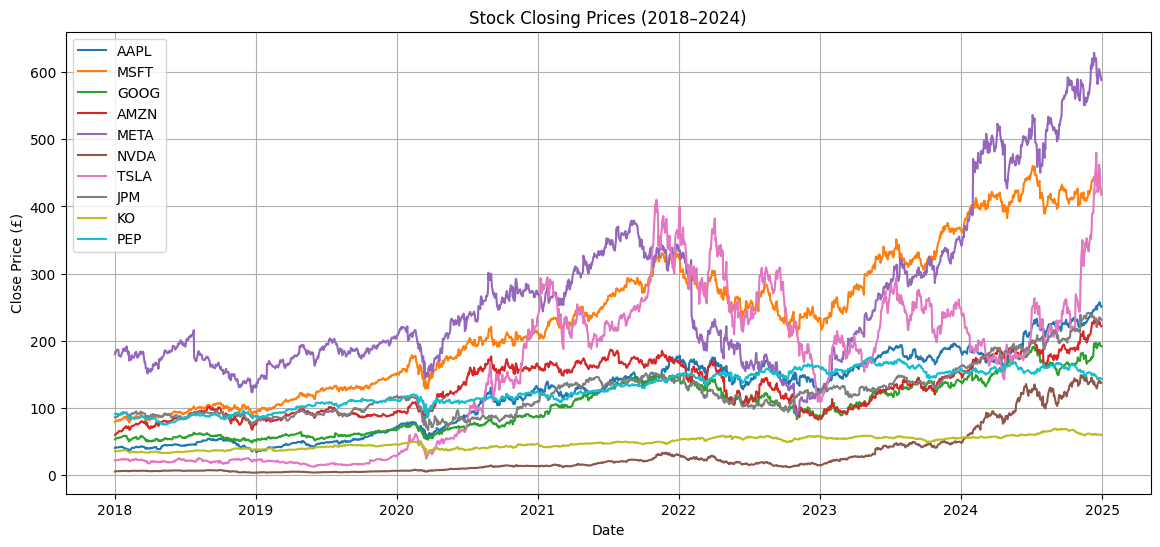

In [7]:
plt.figure(figsize=(14,6))

for ticker in stocks:
    stock = raw_data[raw_data["ticker"] == ticker]

    plt.plot(
        stock["Date"],
        stock["Close"],
        label=ticker
    )

plt.title("Stock Closing Prices (2018–2024)")
plt.xlabel("Date")
plt.ylabel("Close Price (£)")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
raw_data = raw_data.sort_values(
    by=["ticker", "Date"]
).reset_index(drop=True)



In [9]:
raw_data["daily_return"] = (
    raw_data
    .groupby("ticker")["Close"]
    .pct_change()
)

raw_data["volatility20"] = (
    raw_data
    .groupby("ticker")["daily_return"]
    .transform(
        lambda x: x.rolling(20).std()
    )
)
raw_data["price_momentum"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(
        lambda x: x / x.shift(20)
    )
)



In [10]:
raw_data["sma20"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(
        lambda x: x.rolling(20).mean()
    )
)

raw_data["sma50"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(
        lambda x: x.rolling(50).mean()
    )
)

raw_data["price_sma20_ratio"] = (
    raw_data["Close"] /
    raw_data["sma20"]
)

raw_data["price_sma50_ratio"] = (
    raw_data["Close"] /
    raw_data["sma50"]
)

In [11]:
raw_data["sma10"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(
        lambda x: x.rolling(10).mean()
    )
)

raw_data["sma30"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(
        lambda x: x.rolling(30).mean()
    )
)

raw_data["sma_crossover"] = (
    raw_data["sma10"] /
    raw_data["sma30"]
)

In [12]:
raw_data["ema12"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(
        lambda x: x.ewm(span=12, adjust=False).mean()
    )
)

raw_data["price_ema12_ratio"] = (
    raw_data["Close"] /
    raw_data["ema12"]
)



In [13]:
def compute_rsi(close):

    return ta.momentum.RSIIndicator(
        close=close,
        window=14
    ).rsi()


raw_data["rsi14"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(compute_rsi)
)

In [14]:
def compute_macd(close):

    indicator = ta.trend.MACD(close)

    return indicator.macd()


def compute_macd_signal(close):

    indicator = ta.trend.MACD(close)

    return indicator.macd_signal()


raw_data["macd"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(compute_macd)
)

raw_data["macd_signal"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(compute_macd_signal)
)

In [15]:
raw_data["high_low_range"] = (
    raw_data["High"] -
    raw_data["Low"]
) / raw_data["Close"]

In [16]:
raw_data["volume_sma20"] = (
    raw_data
    .groupby("ticker")["Volume"]
    .transform(
        lambda x: x.rolling(20).mean()
    )
)

raw_data["volume_ratio"] = (
    raw_data["Volume"] /
    raw_data["volume_sma20"]
)

In [17]:
feature_data = (
    raw_data
    .dropna()
    .reset_index(drop=True)
)

In [18]:
print(feature_data.info())

feature_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17110 entries, 0 to 17109
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               17110 non-null  datetime64[ns]
 1   ticker             17110 non-null  object        
 2   Open               17110 non-null  float64       
 3   High               17110 non-null  float64       
 4   Low                17110 non-null  float64       
 5   Close              17110 non-null  float64       
 6   Volume             17110 non-null  int64         
 7   daily_return       17110 non-null  float64       
 8   volatility20       17110 non-null  float64       
 9   price_momentum     17110 non-null  float64       
 10  sma20              17110 non-null  float64       
 11  sma50              17110 non-null  float64       
 12  price_sma20_ratio  17110 non-null  float64       
 13  price_sma50_ratio  17110 non-null  float64       
 14  sma10 

Price,Date,ticker,Open,High,Low,Close,Volume,daily_return,volatility20,price_momentum,...,sma30,sma_crossover,ema12,price_ema12_ratio,rsi14,macd,macd_signal,high_low_range,volume_sma20,volume_ratio
0,2018-03-14,AAPL,42.286569,42.333470,41.697950,41.845692,117473600,-0.008501,0.012689,1.085798,...,40.059985,1.040115,41.598934,1.005932,57.986010,0.641527,0.552686,0.015187,140684940.0,0.835012
1,2018-03-15,AAPL,41.859738,42.267784,41.758901,41.894913,90975200,0.001176,0.012249,1.067395,...,40.153005,1.039837,41.644469,1.006014,58.342788,0.617617,0.565672,0.012147,137104720.0,0.663545
2,2018-03-16,AAPL,41.894923,42.005142,41.653379,41.747185,157618800,-0.003526,0.010038,1.029077,...,40.238377,1.038686,41.660272,1.002086,56.784208,0.580062,0.568550,0.008426,134756220.0,1.169659
3,2018-03-19,AAPL,41.583018,41.618193,40.724717,41.109310,133787200,-0.015279,0.010677,1.016644,...,40.359161,1.034694,41.575508,0.988787,50.509775,0.493143,0.553469,0.021734,133410360.0,1.002825
4,2018-03-20,AAPL,41.095242,41.461074,41.024888,41.095242,78597600,-0.000342,0.010635,1.019726,...,40.510696,1.029996,41.501621,0.990208,50.377559,0.418302,0.526435,0.010614,130554140.0,0.602031


In [ ]:
window = 20
episode_length = 252
initial_capital = 100000
transaction_cost = 0.001
number_of_environments = 4
total_timesteps = 100000
ppo_device = "cpu"  # PPO + MlpPolicy is typically faster and more reliable on CPU
ppo_n_steps = 256
ppo_batch_size = 256
ppo_n_epochs = 5

In [ ]:
feature_data = {
    ticker: raw_data[raw_data["ticker"] == ticker].reset_index(drop=True)
    for ticker in stocks
}

AttributeError: 'dict' object has no attribute 'to_csv'

In [ ]:
%%writefile portfolio_env.py
import gymnasium as gym
import numpy as np
import pandas as pd
from gymnasium import spaces


class PortfolioEnv(gym.Env):

    metadata = {"render_modes": ["human"]}

    feature_cols = [
        "daily_return",
        "price_momentum",
        "price_sma20_ratio",
        "price_sma50_ratio",
        "sma_crossover",
        "price_ema12_ratio",
        "rsi14",
        "macd",
        "macd_signal",
        "volatility20",
        "high_low_range",
        "volume_ratio",
    ]

    n_stock_features = len(feature_cols)

    def __init__(
        self,
        feature_data,
        tickers,
        window=20,
        initial_capital=100000,
        transaction_cost=0.001,
        episode_length=252,
    ):

        super().__init__()

        self.tickers = tickers
        self.n_stocks = len(tickers)

        self.window = window
        self.initial_capital = initial_capital
        self.transaction_cost = transaction_cost
        self.episode_length = episode_length

        self._build_arrays(feature_data)

        observation_size = (
            self.window
            * self.n_stocks
            * self.n_stock_features
            + self.n_stocks
            + 1
        )

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(observation_size,),
            dtype=np.float32,
        )

        # Finite PPO logits; step() converts them to portfolio weights with softmax.
        self.action_space = spaces.Box(
            low=-5.0,
            high=5.0,
            shape=(self.n_stocks,),
            dtype=np.float32,
        )

    def _build_arrays(self, feature_data):

        print("build arrays called")

        common_trading_dates = None

        for ticker in self.tickers:

            stock_data = feature_data[ticker].copy()

            stock_data["Date"] = pd.to_datetime(stock_data["Date"])
            stock_data = stock_data.set_index("Date")

            if common_trading_dates is None:
                common_trading_dates = stock_data.index
            else:
                common_trading_dates = (
                    common_trading_dates.intersection(stock_data.index)
                )

        common_trading_dates = common_trading_dates.sort_values()

        self.trading_dates = common_trading_dates
        self.total_trading_days = len(common_trading_dates)

        feature_array = np.zeros(
            (
                self.total_trading_days,
                self.n_stocks,
                self.n_stock_features,
            ),
            dtype=np.float32,
        )

        close_price_array = np.zeros(
            (
                self.total_trading_days,
                self.n_stocks,
            ),
            dtype=np.float32,
        )

        for stock_index, ticker in enumerate(self.tickers):

            stock_data = feature_data[ticker].copy()

            stock_data["Date"] = pd.to_datetime(stock_data["Date"])
            stock_data = stock_data.set_index("Date")

            stock_data = stock_data.loc[common_trading_dates]

            stock_feature_matrix = (
                stock_data[self.feature_cols]
                .fillna(0.0)
                .to_numpy(dtype=np.float32)
            )

            feature_array[:, stock_index, :] = stock_feature_matrix

            close_price_array[:, stock_index] = (
                stock_data["Close"]
                .to_numpy(dtype=np.float32)
            )

        self.feature_array = feature_array
        self.close_price_array = close_price_array

        print("feature array shape      :", self.feature_array.shape)
        print("close price array shape  :", self.close_price_array.shape)
        print("total trading days       :", self.total_trading_days)


    def reset(self, seed=None, options=None):

      super().reset(seed=seed)

      maximum_start_day = (
          self.total_trading_days
          - self.episode_length
          - 1
      )

      if maximum_start_day <= self.window:
          raise ValueError(
              f"Not enough data. Need at least "
              f"{self.window + self.episode_length + 1} trading days, "
              f"got {self.total_trading_days}."
          )

      self.start_day = self.np_random.integers(
          self.window,
          maximum_start_day,
      )

      self.current_day = self.start_day

      self.portfolio_weights = (
          np.ones(
              self.n_stocks,
              dtype=np.float32,
          )
          / self.n_stocks
      )

      self.portfolio_value = self.initial_capital

      self.returns_history = []

      observation = self._get_observation()
      info = self._get_info()

      return observation, info

    def _get_observation(self):
        # Concatenate feature history, portfolio weights, and normalized value
        feature_window = self.feature_array[
            self.current_day - self.window :
            self.current_day
        ]

        flattened_features = feature_window.flatten()

        normalized_portfolio_value = np.array(
            [
                self.portfolio_value /
                self.initial_capital
            ],
            dtype=np.float32
        )

        observation = np.concatenate(
            [
                flattened_features,
                self.portfolio_weights,
                normalized_portfolio_value,
            ]
        )

        return observation.astype(np.float32)

    def _get_info(self) -> dict:

      info = {
          "portfolio_value": self.portfolio_value,

          "portfolio_weights":
              self.portfolio_weights.copy(),

          "current_day":
              self.current_day,

          "date":
              str(self.trading_dates[self.current_day])
              if self.current_day < self.total_trading_days
              else "end",
      }

      if len(self.returns_history) > 1:

          returns_array = np.array(
              self.returns_history
          )

          info["cumulative_return"] = float(
              self.portfolio_value /
              self.initial_capital
              - 1
          )

          info["sharpe_ratio"] = float(
              (
                  returns_array.mean()
                  /
                  (returns_array.std() + 1e-8)
              )
              * np.sqrt(252)
          )

      return info

    def step(self, action: np.ndarray):

      # Convert policy logits to long-only weights.  Unlike abs(), this gives
      # each action a unique meaning and is easier for PPO to optimise.
      logits = np.clip(action.astype(np.float32), -20.0, 20.0)
      logits -= logits.max()
      exp_logits = np.exp(logits)
      new_weights = exp_logits / (exp_logits.sum() + 1e-8)

      current_prices = self.close_price_array[
          self.current_day
      ]

      next_prices = self.close_price_array[
          self.current_day + 1
      ]

      stock_returns = (
          next_prices - current_prices
      ) / (current_prices + 1e-8)

      portfolio_return = np.dot(
          new_weights,
          stock_returns
      )

      weight_change = np.abs(
          new_weights - self.portfolio_weights
      ).sum()

      transaction_cost = (
          self.transaction_cost *
          weight_change
      )

      net_return = (
          portfolio_return -
          transaction_cost
      )

      # Reward relative outperformance versus a daily equal-weight benchmark.
      # Portfolio value below still uses the actual net return.
      equal_weight_return = stock_returns.mean()
      reward = float(
          np.log1p(max(net_return, -0.999))
          - np.log1p(max(equal_weight_return, -0.999))
      )

      self.portfolio_value *= (
          1.0 + net_return
      )

      self.portfolio_weights = new_weights

      self.current_day += 1

      self.returns_history.append(
          net_return
      )

      days_elapsed = (
          self.current_day -
          self.start_day
      )

      terminated = (
          days_elapsed >=
          self.episode_length
      )

      truncated = False

      observation = self._get_observation()

      info = self._get_info()

      return (
          observation,
          reward,
          terminated,
          truncated,
          info

      )

    def _max_drawdown(self) -> float:
        # Returns drawdown as negative ratio relative to peak
        if len(self.returns_history) == 0:
            return 0.0

        portfolio_values = (
            self.initial_capital *
            np.cumprod(
                1 + np.array(self.returns_history)
            )
        )

        peak_values = np.maximum.accumulate(
            portfolio_values
        )

        drawdowns = (
            portfolio_values - peak_values
        ) / (peak_values + 1e-8)

        return float(drawdowns.min())

    def get_episode_metrics(self) -> dict:
        # Compute Sharpe, cumulative return, volatility, max drawdown, win rate
        if len(self.returns_history) == 0:
            return {}

        returns = np.array(
            self.returns_history
        )

        cumulative_return = (
            self.portfolio_value /
            self.initial_capital
            - 1
        )

        annualized_return = (
            (1 + cumulative_return)
            **
            (252 / len(returns))
            - 1
        )

        volatility = (
            returns.std()
            *
            np.sqrt(252)
        )

        sharpe_ratio = (
            returns.mean()
            /
            (returns.std() + 1e-8)
            *
            np.sqrt(252)
        )

        max_drawdown = self._max_drawdown()

        win_rate = (
            returns > 0
        ).mean()

        return {

            "cumulative_return":
                float(cumulative_return * 100),

            "annualized_return":
                float(annualized_return * 100),

            "volatility":
                float(volatility * 100),

            "sharpe_ratio":
                float(sharpe_ratio),

            "max_drawdown":
                float(max_drawdown * 100),

            "win_rate":
                float(win_rate * 100),

            "final_portfolio_value":
                float(self.portfolio_value),

            "total_steps":
                len(returns)
        }

    def render(self):

      print("Step:", self.current_day)
      print("Portfolio Value:", self.portfolio_value)

      print(
          "Return:",
          (self.portfolio_value / self.initial_capital - 1) * 100,
          "%"
      )

      print(
          "Weights:",
          self.portfolio_weights
      )


In [ ]:
train_data = {}
validation_data = {}
test_data = {}

for ticker, df in feature_data.items():

    df = df.sort_values("Date").reset_index(drop=True)

    train_data[ticker] = df[
        df["Date"] < "2022-01-01"
    ].reset_index(drop=True)

    validation_data[ticker] = df[
        (df["Date"] >= "2022-01-01") &
        (df["Date"] < "2023-07-01")
    ].reset_index(drop=True)

    test_data[ticker] = df[
        df["Date"] >= "2023-07-01"
    ].reset_index(drop=True)

print("=" * 60)
print("DATASET SPLIT SUMMARY")
print("=" * 60)

for ticker in feature_data.keys():

    print(
        ticker,
        "| Train:",
        len(train_data[ticker]),
        "| Val:",
        len(validation_data[ticker]),
        "| Test:",
        len(test_data[ticker])
    )

print("\nRequired minimum days:")
print(window + episode_length + 1)

In [ ]:
print(type(feature_data))

In [ ]:
from portfolio_env import PortfolioEnv
from gymnasium.utils.env_checker import check_env

print("Building environment...")

env = PortfolioEnv(
    feature_data=feature_data,
    tickers=stocks,
    window=20,
    initial_capital=10000,
    transaction_cost=0.001,
    episode_length=252
)

print("Running Gymnasium checker...")

check_env(env)

print("Environment check passed!")

print("\n[ENVIRONMENT CONFIGURATION]")
print("Number of stocks        :", env.n_stocks)
print("Stocks                  :", env.tickers)
print("Total trading days      :", env.total_trading_days)
print("Lookback window         :", env.window)
print("Episode length          :", env.episode_length)
print("Initial capital         :", env.initial_capital)
print("Transaction cost        :", env.transaction_cost)

print("\n[DATA ARRAYS]")
print("Feature array shape     :", env.feature_array.shape)
print("Close price array shape :", env.close_price_array.shape)
print("Number of features      :", env.n_stock_features)

print("\n[GYM SPACES]")
print("Observation space       :", env.observation_space)
print("Action space            :", env.action_space)

print("\n[RANDOM AGENT TEST]")

obs, info = env.reset()
print("Observation shape       :", obs.shape)

total_reward = 0
terminated = False
truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

print("Total reward            :", round(total_reward, 4))

print("\n[EPISODE PERFORMANCE METRICS]")

metrics = env.get_episode_metrics()
for key, value in metrics.items():
    if isinstance(value, float):
        print(f"{key:25s}: {value:.4f}")
    else:
        print(f"{key:25s}: {value}")

print("\n" + "="*60)
print("ENVIRONMENT VALIDATION COMPLETED")
print("="*60)

In [ ]:
!pip install stable-baselines3


In [ ]:
# PPO training: CPU avoids the MLP/CUDA slowdown in Stable-Baselines3.
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

def make_train_env():
    return PortfolioEnv(
        feature_data=train_data, tickers=stocks, window=window,
        initial_capital=initial_capital, transaction_cost=transaction_cost,
        episode_length=episode_length,
    )

train_environment = DummyVecEnv([make_train_env for _ in range(number_of_environments)])

print('device:', ppo_device)
print('parallel environments:', number_of_environments)

model = PPO(
    'MlpPolicy', train_environment,
    device=ppo_device,
    n_steps=ppo_n_steps,
    batch_size=ppo_batch_size,
    n_epochs=ppo_n_epochs,
    verbose=1,
    tensorboard_log='./logs/',
)

model.learn(total_timesteps=total_timesteps, progress_bar=False)
model.save('ppo_portfolio')

# Evaluate on held-out test data.  The plotting cell below expects these names.
def run_policy(policy, seed=42):
    evaluation_env = PortfolioEnv(
        feature_data=test_data, tickers=stocks, window=window,
        initial_capital=initial_capital, transaction_cost=transaction_cost,
        episode_length=episode_length,
    )
    observation, _ = evaluation_env.reset(seed=seed)
    terminated = truncated = False
    while not (terminated or truncated):
        action = policy(observation, evaluation_env)
        observation, _, terminated, truncated, _ = evaluation_env.step(action)
    return evaluation_env.get_episode_metrics()

ppo_metrics = [run_policy(
    lambda observation, _: model.predict(observation, deterministic=True)[0]
)]
benchmark_metrics = {
    'equal_weight': run_policy(
        lambda _, env: np.ones(env.n_stocks, dtype=np.float32) / env.n_stocks
    ),
    'random': run_policy(
        lambda _, env: env.action_space.sample()
    ),
}
print('PPO test metrics:', ppo_metrics[0])

In [ ]:
import psutil

print("CPU usage:", psutil.cpu_percent(), "%")
print("RAM usage:", psutil.virtual_memory().percent, "%")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def get_portfolio_trace(policy, seed=42):
    env = PortfolioEnv(
        feature_data=test_data,
        tickers=stocks,
        window=window,
        initial_capital=initial_capital,
        transaction_cost=transaction_cost,
        episode_length=episode_length,
    )

    observation, _ = env.reset(seed=seed)
    dates = [env.trading_dates[env.current_day]]
    values = [env.portfolio_value]

    terminated = truncated = False
    while not (terminated or truncated):
        action = policy(observation, env)
        observation, _, terminated, truncated, _ = env.step(action)

        dates.append(env.trading_dates[env.current_day])
        values.append(env.portfolio_value)

    values = np.asarray(values, dtype=float)
    daily_returns = pd.Series(values[1:]).pct_change().fillna(0).to_numpy()

    cumulative_return = (values / initial_capital - 1) * 100
    rolling_sharpe = (
        pd.Series(daily_returns)
        .rolling(20)
        .mean()
        .div(pd.Series(daily_returns).rolling(20).std() + 1e-8)
        .mul(np.sqrt(252))
        .to_numpy()
    )
    rolling_sharpe = np.insert(rolling_sharpe, 0, np.nan)

    running_peak = np.maximum.accumulate(values)
    drawdown = (values / running_peak - 1) * 100

    return dates, cumulative_return, rolling_sharpe, drawdown


strategies = {
    "PPO": lambda obs, _: model.predict(obs, deterministic=True)[0],
    "Equal Weight": lambda _, env: np.ones(
        env.n_stocks, dtype=np.float32
    ) / env.n_stocks,
    "Random": lambda _, env: env.action_space.sample(),
}

colors = {
    "PPO": "#2ecc71",
    "Equal Weight": "#3498db",
    "Random": "#e74c3c",
}

results = {
    name: get_portfolio_trace(policy)
    for name, policy in strategies.items()
}

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

for name, (dates, cumulative, sharpe, drawdown) in results.items():
    axes[0].plot(dates, cumulative, label=name, color=colors[name], linewidth=2)
    axes[1].plot(dates, sharpe, label=name, color=colors[name], linewidth=2)
    axes[2].plot(dates, drawdown, label=name, color=colors[name], linewidth=2)

axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Cumulative Return")
axes[0].set_ylabel("Return (%)")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("20-Day Rolling Sharpe Ratio")
axes[1].set_ylabel("Sharpe Ratio")
axes[1].grid(alpha=0.25)

axes[2].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[2].set_title("Portfolio Drawdown")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Drawdown (%)")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()